## 3. Preparing the data for analysis and data exploration and visualization

### 3.1 Data cleaning and prep
This part of the project involves loading the data into structured tables, cleaning it for analysis and then later merging the tables together into one long form panel data table, that makes it easy and efficient to analyse. Main part of data cleaning involves checking again the time frame of the saved observations and removing unnecessary ones, renaming columns into more readable ones and dealing with missing data.

In [1]:
import pandas as pd
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from sklearn.preprocessing import StandardScaler

In [4]:
#Loading the names and appids of the analysed games
top_games = pd.read_csv('data/game_filtering/filtered_games_by_data.csv', sep=',')


In [5]:
start_2025 = pd.to_datetime('2025-01-01')
end_2025 = pd.to_datetime('2025-12-31')

In [6]:
#Loading the data for player counts, filtering observations based on the time frame and merging all the data into a single table

player_counts = []
folder = 'data/player_counts_2025'
for filename in os.listdir(folder):
    if filename.endswith('.csv'):
        df = pd.read_csv(os.path.join(folder, filename), index_col = 0, sep = ';')
        df.index = pd.to_datetime(df.index)
        appid = re.search(r'\d+', filename).group()
        df.rename(columns={"Players" : int(appid)}, inplace=True)
        df.drop(columns=['Average Players'], inplace=True)
        df = df.loc[(df.index >= start_2025) & (df.index <= end_2025)]
        player_counts.append(df)

player_counts_df = pd.concat(player_counts, axis=1)


In [7]:
#Checking the table for missing values
player_counts_df.isna().sum()

105600     0
107410     0
1085660    0
108600     0
1091500    0
          ..
916440     0
945360     0
960090     0
961200     0
962130     0
Length: 113, dtype: int64

There seems to be no missing data for the player counts table, therefore no further action is needed.

In [8]:
#Loading the data for twitch viewership counts, filtering observations based on the time frame and merging all the data into a single table

twitch_counts = []
folder = 'data/2025_twitch_views'
for filename in os.listdir(folder):
    if filename.endswith('.csv'):
        df = pd.read_csv(os.path.join(folder, filename), index_col=0)
        df.index = pd.to_datetime(df.index, format = 'mixed')
        appid = re.search(r'\d+', filename).group()
        df.rename(columns={"value" : int(appid)}, inplace=True)
        df.drop(columns=['chans'], inplace=True)
        twitch_counts.append(df)

twitch_counts_df = pd.concat(twitch_counts, axis=1)

In [9]:
#Checking the table for missing data

missing_data = twitch_counts_df.isna().sum()
missing_data = missing_data[missing_data > 0]
missing_data.sort_values(ascending=False, inplace=True)
missing_data

250900     273
387990     244
2050650    240
945360     190
767560     127
2840770     51
1272080     43
602960      39
218620      21
784080      17
1229490     17
1363080     15
312520      15
1716740     10
284160       9
281990       8
613100       5
916440       5
1446780      4
2186680      4
1973530      4
287700       3
1144200      1
dtype: int64

There are some games with many missing observations. These will be dropped completely, because filling those observations artificially could alter the time series significantly. For games with less than 50 missing observations, which seems more reasonable for a 365 day analysis period, the backwards fill method will be used which fills missing observations with the value from their previous valid observation. This should not affect the final time series greatly, especially because after analysing the twitch_counts table itself it seems that the missing observations are spread throughout the whole time period and are not clustered together.

In [10]:
for col in twitch_counts_df.columns:
    if col in missing_data[missing_data > 50].index:
        twitch_counts_df.drop(columns=[col], inplace=True)
    else:
        twitch_counts_df.ffill(inplace=True)

if twitch_counts_df.isna().sum().sum() > 0:
    twitch_counts_df.bfill(inplace=True)

In [11]:
#Checking if there is any remaining missing data left
missing_data = twitch_counts_df.isna().sum()
missing_data[missing_data > 0]

Series([], dtype: int64)

In [12]:
#Making sure that games which have been dropped because of missing Twitch observations will also be dropped from the player counts table
for col in player_counts_df.columns:
    if col not in twitch_counts_df.columns:
        player_counts_df.drop(columns=[col], inplace=True)

In [13]:
#Saving results for reproducibility
player_counts_df.to_csv('data/dataframes/player_counts_2025.csv')
twitch_counts_df.to_csv('data/dataframes/twitch_counts_2025.csv')

In [14]:
#Loading the results of sentiment analysis

review_sentiment = pd.read_csv('data/dataframes/average_sentiment_reviews_daily.csv')
reddit_sentiment = pd.read_csv('data/dataframes/average_sentiment_reddit_daily.csv')

In [15]:
#Verifying the completeness of review and reddit sentiment data
days_per_game_review = review_sentiment.groupby('appid')['date'].nunique()
print(days_per_game_review.value_counts())

date
365    95
364     6
328     2
359     2
343     1
326     1
358     1
351     1
327     1
361     1
362     1
360     1
Name: count, dtype: int64


In [16]:
print(days_per_game_review[days_per_game_review < 365])

appid
216150     343
266410     328
281990     326
387990     364
394360     328
728880     364
767560     358
784080     351
916440     364
961200     359
1158310    327
1272080    364
1282270    364
1343370    361
1401590    362
1599340    360
1818450    364
2840770    359
Name: date, dtype: int64


In [17]:
print(f"Number of games before filtering: {review_sentiment['appid'].nunique()}")

complete_games_review = days_per_game_review[days_per_game_review == 365].index
review_sentiment = review_sentiment[review_sentiment['appid'].isin(complete_games_review)]

print(f"Number of games after filtering: {review_sentiment['appid'].nunique()}")

Number of games before filtering: 113
Number of games after filtering: 95


In [18]:
days_per_game_reddit = reddit_sentiment.groupby('appid')['date'].nunique()
print(days_per_game_reddit.value_counts())

date
365    97
358     1
364     1
359     1
363     1
Name: count, dtype: int64


In [19]:
print(days_per_game_reddit[days_per_game_reddit != 365])

appid
244210.0     358
380600.0     364
916440.0     359
1363080.0    363
Name: date, dtype: int64


In [20]:
print(f"Number of games before filtering: {reddit_sentiment['appid'].nunique()}")

complete_games_reddit = days_per_game_reddit[days_per_game_reddit == 365].index
reddit_sentiment = reddit_sentiment[reddit_sentiment['appid'].isin(complete_games_reddit)]

print(f"Number of games after filtering: {reddit_sentiment['appid'].nunique()}")

Number of games before filtering: 101
Number of games after filtering: 97


In [21]:
player_counts_df = pd.read_csv('data/dataframes/player_counts_2025.csv', index_col=0)
twitch_counts_df = pd.read_csv('data/dataframes/twitch_counts_2025.csv', index_col=0)

### 3.2 Merging all data into one dataframe for panel data
In order to form one table with all the data in the form of panel data, the tables need to be prepared appropriately. Because the player_counts and twitch_counts tables have data for each game in separate columns they need to be converted to long form data, columns are renamed to be more readable and appropriate for merging and the dates are normalized to midnight to avoid problems with grouping.

In [22]:
#Cleaning all the tables

player_counts_df.reset_index(inplace=True)
twitch_counts_df.reset_index(inplace=True)
player_counts_df.rename(columns={'DateTime': 'date'}, inplace=True)
twitch_counts_df.rename(columns={'day': 'date'}, inplace=True)

player_counts_df = player_counts_df.melt(id_vars='date', var_name='appid', value_name='player_count')
twitch_counts_df = twitch_counts_df.melt(id_vars='date', var_name='appid', value_name='twitch_count')

review_sentiment.rename(columns={'sentiment_binary': 'review_sentiment'}, inplace=True)
reddit_sentiment.rename(columns={'sentiment_binary': 'reddit_sentiment'}, inplace=True)

player_counts_df['appid'] = player_counts_df['appid'].astype(int)
twitch_counts_df['appid'] = twitch_counts_df['appid'].astype(int)
review_sentiment['appid'] = review_sentiment['appid'].astype(int)
reddit_sentiment['appid'] = reddit_sentiment['appid'].astype(int)

player_counts_df['date'] = pd.to_datetime(player_counts_df['date']).dt.normalize()
twitch_counts_df['date'] = pd.to_datetime(twitch_counts_df['date']).dt.normalize()
review_sentiment['date'] = pd.to_datetime(review_sentiment['date']).dt.normalize()
reddit_sentiment['date'] = pd.to_datetime(reddit_sentiment['date']).dt.normalize()

C:\Users\magda\AppData\Local\Temp\ipykernel_2104\1743039846.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  player_counts_df.reset_index(inplace=True)
C:\Users\magda\AppData\Local\Temp\ipykernel_2104\1743039846.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  twitch_counts_df.reset_index(inplace=True)


In [23]:
#Merging all the tables using inner join, to avoid missing data and keep in mind some games were dropped because of missing data earlier

panel_data = pd.merge(player_counts_df, twitch_counts_df, on=['date', 'appid'], how='inner')
panel_data = pd.merge(panel_data, review_sentiment[['date', 'appid', 'review_sentiment']], on=['date', 'appid'], how='inner')
panel_data = pd.merge(panel_data, reddit_sentiment[['date', 'appid', 'reddit_sentiment', 'post_count']], on=['date', 'appid'], how='inner')
panel_data = pd.merge(panel_data, top_games[['appid', 'name']], on='appid', how='inner')
panel_data = panel_data[['date', 'appid', 'name', 'player_count', 'twitch_count', 'review_sentiment', 'reddit_sentiment', 'post_count']]
panel_data.sort_values(by=['appid', 'date'], inplace=True)
panel_data.reset_index(drop=True, inplace=True)

panel_data.head()

,date,appid,name,player_count,twitch_count,review_sentiment,reddit_sentiment,post_count
0,2025-01-01,570,Dota 2,638080.0,24898.0,0.93,0.70,258
1,2025-01-02,570,Dota 2,648021.0,27474.0,1.00,0.77,298
2,2025-01-03,570,Dota 2,686353.0,34790.0,0.99,0.74,336
3,2025-01-04,570,Dota 2,710477.0,33816.0,0.92,0.76,296
4,2025-01-05,570,Dota 2,695257.0,33035.0,0.93,0.73,316


In [24]:
#Saving the table for reproducibility
panel_data.to_csv('data/dataframes/panel_data_2025.csv', index = False)

In [2]:
panel_data = pd.read_csv('data/dataframes/panel_data_2025.csv')

### 3.3 Data Exploration and Visualization
Po pomyślnym oczyszczeniu i połączeniu danych w jeden panel, przechodzimy do eksploracyjnej analizy danych (EDA). Celem tej sekcji jest:
1. Weryfikacja spójności i kompletności ostatecznego zbioru.
2. Zrozumienie rozkładu statystycznego kluczowych zmiennych.
3. Identyfikacja trendów w czasie oraz zjawisk sezonowych (w ujęciu dziennym i tygodniowym).
4. Zbadanie zależności (korelacji) pomiędzy aktywnością graczy, widownią na Twitchu a sentymentem.

In [16]:
sns.set_theme(style="darkgrid")
sns.set_palette("colorblind")
plt.style.use('seaborn-v0_8-whitegrid')

In [17]:
#Checking the number of total observations and data types
panel_data["date"] = pd.to_datetime(panel_data["date"])
print(panel_data.shape)
print(panel_data.dtypes)

(29565, 8)
date                datetime64[us]
appid                        int64
name                           str
player_count               float64
twitch_count               float64
review_sentiment           float64
reddit_sentiment           float64
post_count                   int64
dtype: object


In [177]:
panel_data.head()

,date,appid,name,player_count,twitch_count,review_sentiment,reddit_sentiment,post_count
0,2025-01-01,570,Dota 2,638080.0,24898.0,0.93,0.70,258
1,2025-01-02,570,Dota 2,648021.0,27474.0,1.00,0.77,298
2,2025-01-03,570,Dota 2,686353.0,34790.0,0.99,0.74,336
3,2025-01-04,570,Dota 2,710477.0,33816.0,0.92,0.76,296
4,2025-01-05,570,Dota 2,695257.0,33035.0,0.93,0.73,316


In [178]:
print("Liczba gier:", panel_data["appid"].nunique())
print("Liczba dni:", panel_data["date"].nunique())
print("Liczba obserwacji:", len(panel_data))

Liczba gier: 81
Liczba dni: 365
Liczba obserwacji: 29565


In [179]:
#Checking if every game has the whole year worth of data
observations_per_game = panel_data.groupby("appid").size()
print(observations_per_game.value_counts().sort_index())

365    81
Name: count, dtype: int64


In [180]:
#Checking if there are no duplicate rows
duplicates = panel_data.duplicated(["appid", "date"]).sum()

print("Duplikaty appid + data:", duplicates)

Duplikaty appid + data: 0


#### 3.3.1 Podstawowe statystyki opisowe
Sprawdzenie spójności panelu potwierdziło, że posiadamy kompletne dane dla 81 gier przez 365 dni, co daje równe 29 565 obserwacji bez duplikatów. 
Poniższa tabela `describe` przedstawia podstawowe statystyki opisowe zmiennych.

In [4]:
variables = [
    "player_count",
    "twitch_count",
    "post_count",
    "reddit_sentiment",
    "review_sentiment"
]

panel_data[variables].describe().T

,count,mean,std,min,25%,50%,75%,max
player_count,29565.0,42139.292677,110560.078589,692.0,5360.00,15211.00,31679.00,1347327.0
twitch_count,29565.0,2860.954778,9224.015654,19.0,127.00,429.00,1641.00,367429.0
post_count,29565.0,244.140369,391.008188,2.0,72.00,136.00,254.00,9270.0
reddit_sentiment,29565.0,0.729591,0.091452,0.0,0.67,0.73,0.79,1.0
review_sentiment,29565.0,0.905399,0.077999,0.0,0.87,0.92,0.96,1.0


In [5]:
variables_no_player_count = [
        "twitch_count",
        "post_count",
        "reddit_sentiment",
        "review_sentiment"
]

In [183]:
print(panel_data["name"].unique())

<ArrowStringArray>
[                         'Dota 2',                     'Garry's Mod',
        'FINAL FANTASY XIV Online',                        'Terraria',
                 'Project Zomboid',                        'Warframe',
                          'Kenshi',                     'War Thunder',
                   'Path of Exile',                   '7 Days to Die',
                            'Rust',                         'Cuphead',
                    'No Man's Sky',                    'BeamNG.drive',
                      'Brawlhalla',                        'RimWorld',
                      'FOR HONOR™',                      'Rain World',
           'ARK: Survival Evolved',                 'DARK SOULS™ III',
                       'Fallout 4',                       'Undertale',
                  'Stardew Valley',                        'Factorio',
                          'VRChat',    'theHunter: Call of the Wild™',
                    'Satisfactory',               'World o

In [184]:
print(panel_data["appid"].unique())

[    570    4000   39210  105600  108600  230410  233860  236390  238960
  251570  252490  268910  275850  284160  291550  294100  304390  312520
  346110  374320  377160  391540  413150  427520  438100  518790  526870
  552990  553850  570940  578080  582010  582660  594650  602960  613100
  686810  739630  753640  892970  960090  962130 1085660 1091500 1142710
 1144200 1145360 1151340 1172470 1196590 1203620 1222670 1229490 1240440
 1245620 1286830 1313140 1326470 1364780 1384160 1407200 1446780 1449850
 1465360 1604030 1659040 1665460 1716740 1778820 1966720 1973530 2074920
 2186680 2300320 2322010 2325290 2358720 2379780 2537590 2707930 2767030]


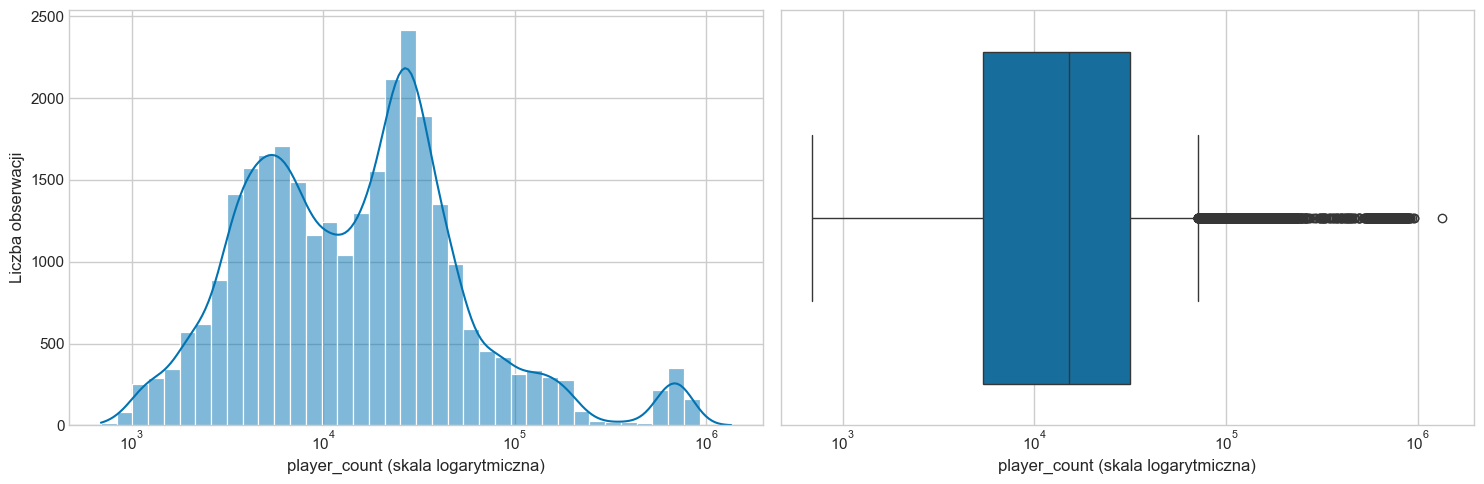

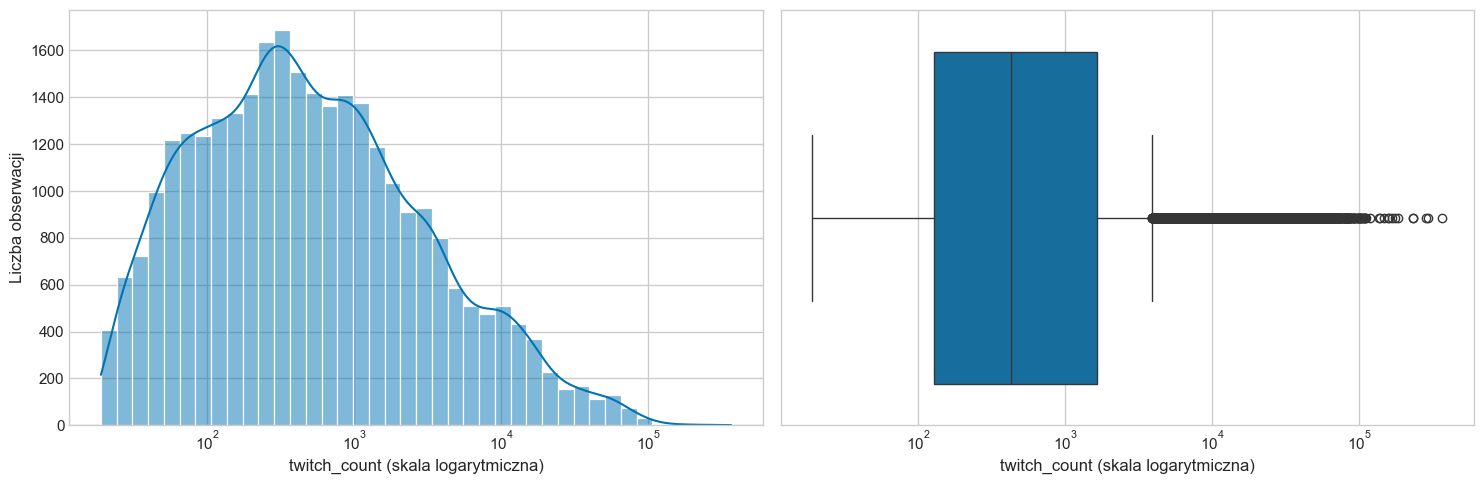

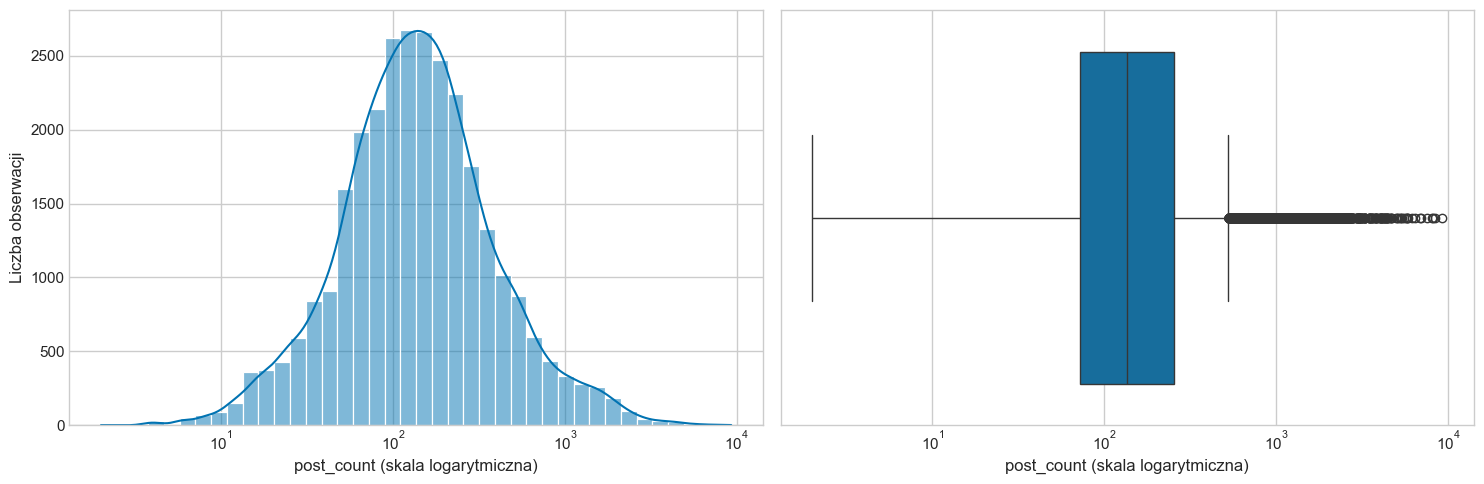

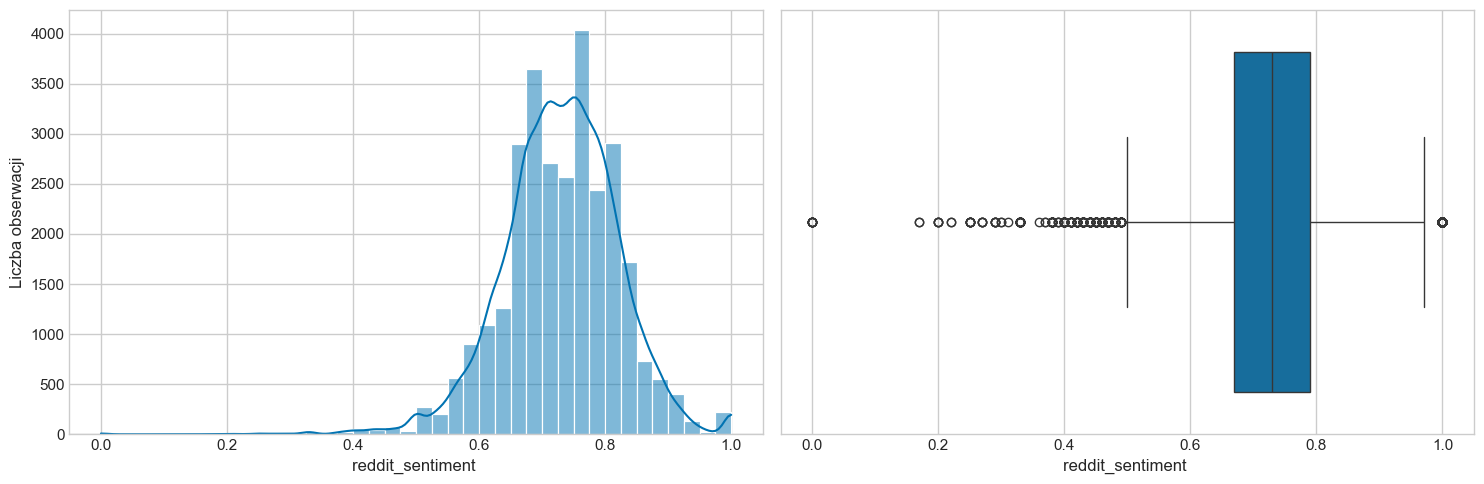

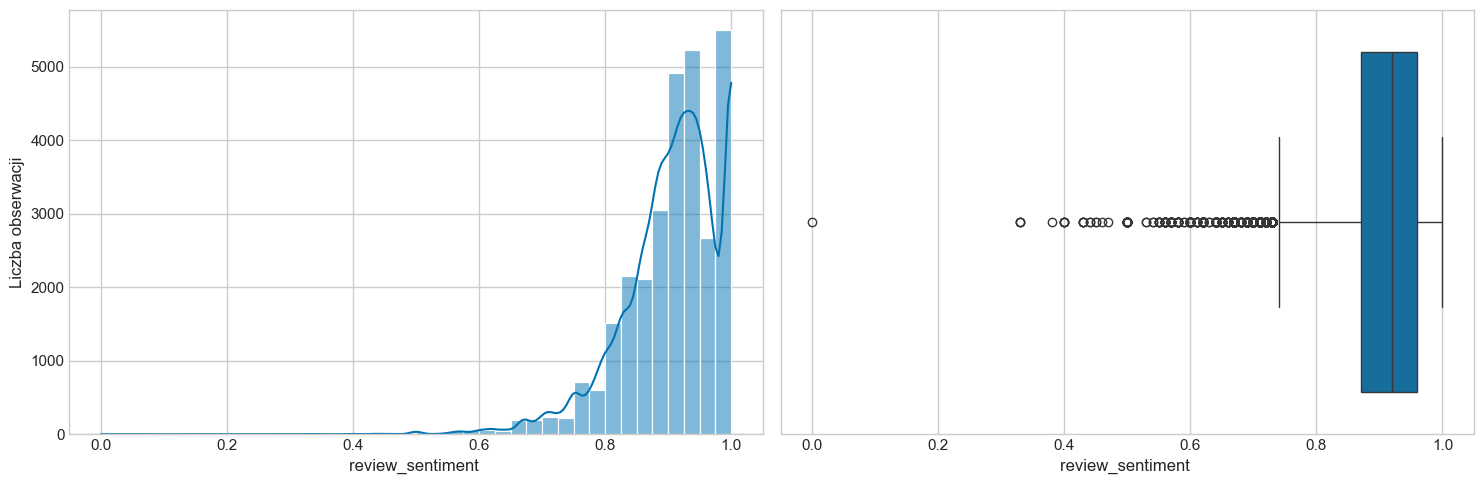

In [6]:
skewed_vars = ["player_count", "twitch_count", "post_count"]
sentiment_vars = ["reddit_sentiment", "review_sentiment"]

for variable in variables:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    use_log = variable in skewed_vars
    
    sns.histplot(data=panel_data, x=variable, bins=40, kde=True, ax=axes[0], log_scale=use_log)
    #axes[0].set_title(f'Histogram rozkładu: {variable}')
    axes[0].set_ylabel('Liczba obserwacji')
    axes[0].set_xlabel(f'{variable} {"(skala logarytmiczna)" if use_log else ""}')
    
    sns.boxplot(data=panel_data, x=variable, ax=axes[1])
    if use_log:
        axes[1].set_xscale('log')
    #axes[1].set_title(f'Wykres pudełkowy (Boxplot): {variable}')
    axes[1].set_xlabel(f'{variable} {"(skala logarytmiczna)" if use_log else ""}')
    
    plt.tight_layout()
    plt.show()

#### 3.3.2 Wizualizacja szeregów czasowych – Wybrane tytuły
Ze względu na różnice w skali popularności między różnymi grami, nałożenie wszystkich 81 tytułów na jeden wykres spowodowałoby jego nieczytelność. 

Dlatego w pierwszym kroku wyodrębniono podzbiór trzech losowych gier i analizujemy trend dziennej liczby aktywnych graczy `player_count`. Pozwala to na wstępną ocenę wahań – już na tym etapie można zauważyć cykliczne, krótkoterminowe "szczyty" oraz nagłe skoki, które mogą być powiązane z aktualizacjami gry lub wyprzedażami.

In [18]:
selected_games = [251570,252490,268910]

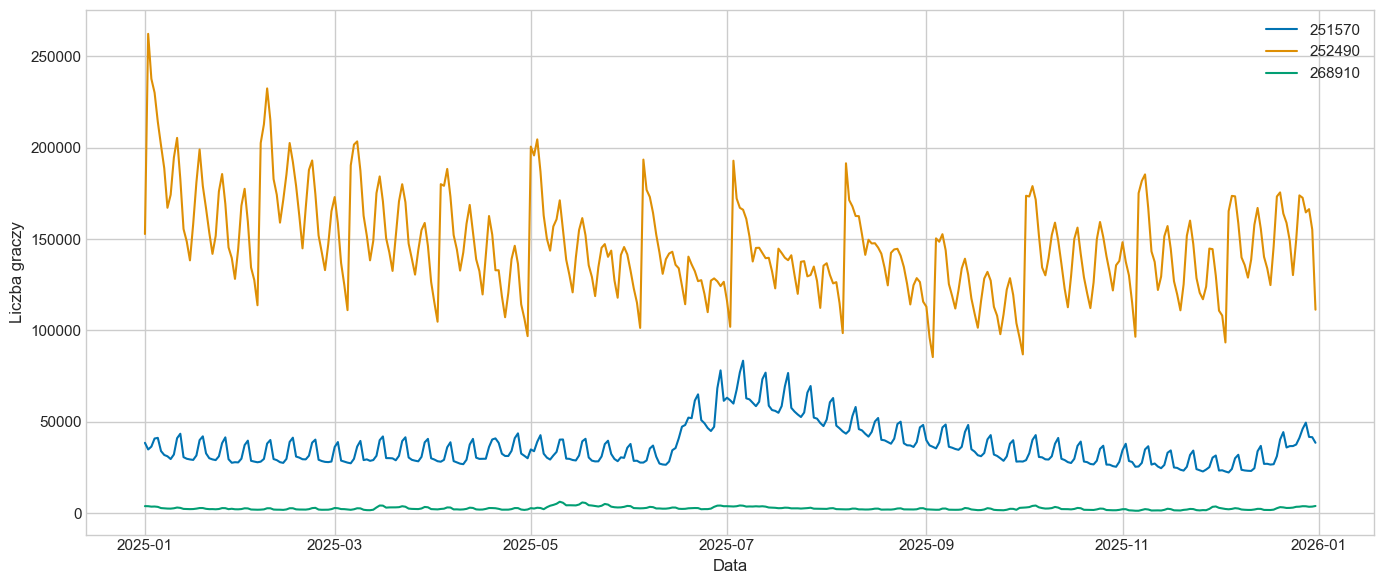

In [19]:
subset = panel_data[panel_data["appid"].isin(selected_games)]

plt.figure(figsize=(14, 6))

for game in selected_games:
    game_data = subset[subset["appid"] == game]
    
    plt.plot(
        game_data["date"],
        game_data["player_count"],
        label=str(game)
    )

#plt.title("Dzienna liczba aktywnych graczy – wybrane gry")
plt.xlabel("Data")
plt.ylabel("Liczba graczy")
plt.legend()

plt.tight_layout()
plt.show()

Sprawdzono zachowanie pozostałych zmiennych (Twitch, posty, sentyment) dla tych samych trzech wybranych gier. Oddzielne wykresy (subplots) są konieczne, ponieważ zmienne te mają różne jednostki (np. tysiące widzów vs sentyment w skali 0-1). 
Wykresy te pozwalają wizualnie ocenić, czy szczyty oglądalności na Twitchu pokrywają się ze zwiększoną aktywnością graczy lub skokami liczby postów na platformie Reddit.

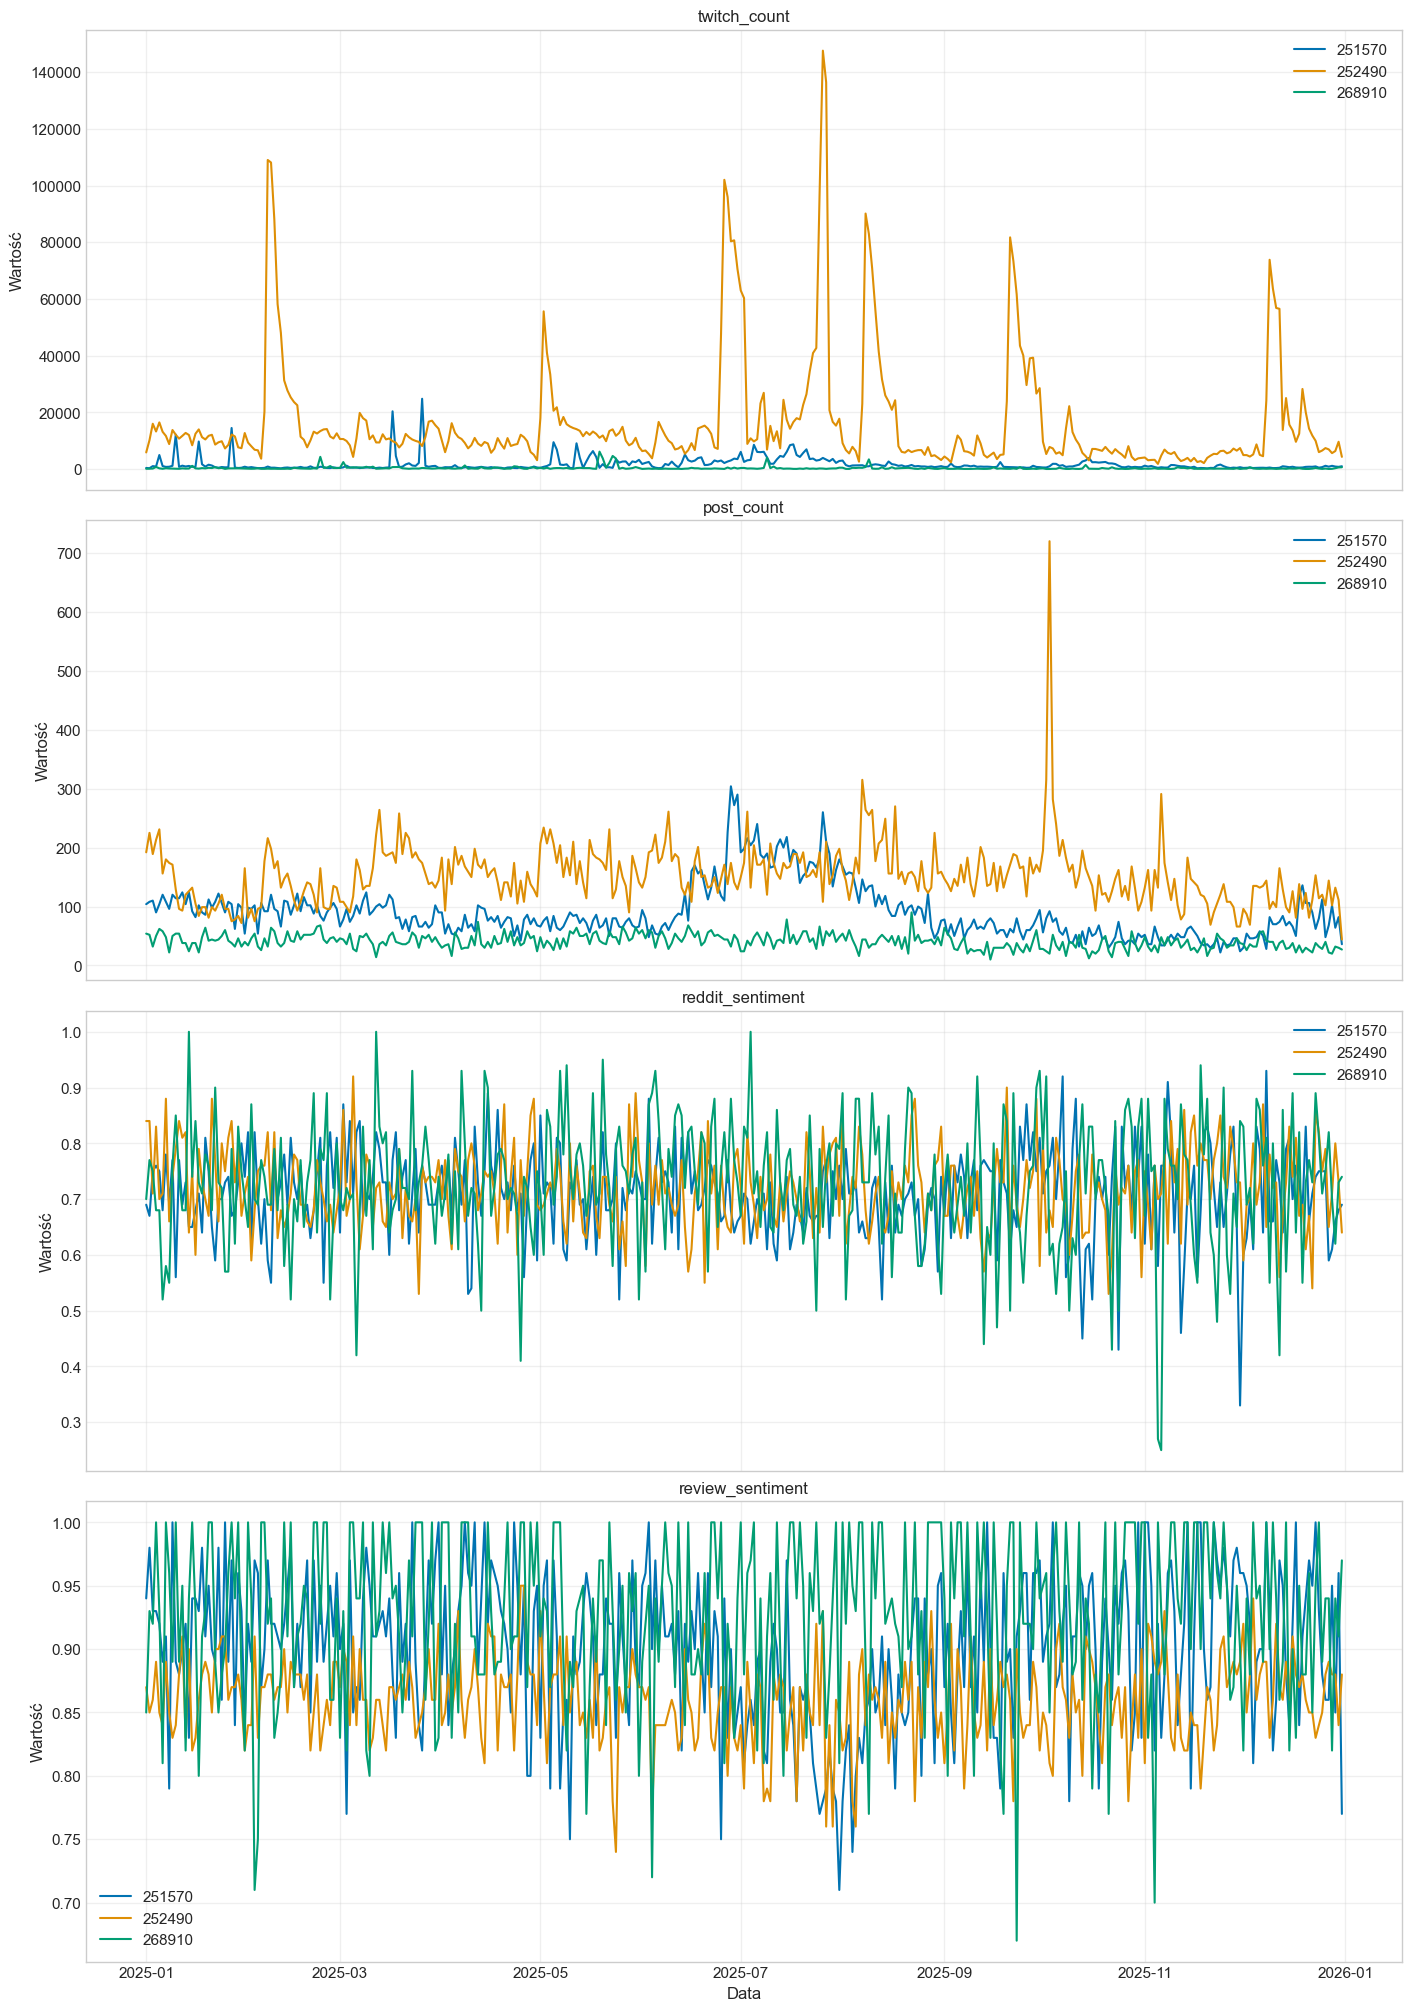

In [20]:
subset = panel_data[panel_data["appid"].isin(selected_games)]

fig, axes = plt.subplots(
    4, 1,
    figsize=(14, 5* len(variables_no_player_count)),
    sharex=True,
    layout="constrained"
)

for ax, variable in zip(axes, variables_no_player_count):
    for game in selected_games:
        game_data = subset[subset["appid"] == game]
    
        ax.plot(
            game_data["date"],
            game_data[variable],
            label=str(game)
        )
    
    ax.set_title(variable)
    ax.set_ylabel("Wartość")
    ax.grid(alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("Data")

#fig.suptitle(
#    "Zmiany wartości zmiennych w czasie dla wybranych gier",
#    fontsize=16
#)

plt.show()

Aby móc nałożyć wszystkie pięć metryk na jeden wykres dla pojedynczej gry i zbadać ich wzajemne współwystępowanie, potrzeba ujednolicić ich skalę. 

W tym celu wykorzystano `StandardScaler`, który przekształca wartości tak, aby ich średnia wynosiła 0, a odchylenie standardowe 1. Wartości na wykresie będą od teraz interpretowane jako siła odchylenia od normy.

In [21]:
days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

panel_data["weekday"] = pd.Categorical(
    panel_data["date"].dt.day_name(),
    categories=days_order,
    ordered=True
)

panel_data["week"] = panel_data["date"].dt.isocalendar().week

In [22]:
scaler = StandardScaler()
panel_data_scaled = panel_data.copy()
panel_data_scaled[variables] = scaler.fit_transform(panel_data[variables])
panel_data_scaled.head(10)

,date,appid,name,player_count,twitch_count,review_sentiment,reddit_sentiment,post_count,weekday,week
0,2025-01-01,570,Dota 2,5.390289,2.389135,0.315404,-0.323576,0.035446,Wednesday,1
1,2025-01-02,570,Dota 2,5.480206,2.668411,1.212870,0.441868,0.137748,Thursday,1
2,2025-01-03,570,Dota 2,5.826919,3.461571,1.084660,0.113821,0.234934,Friday,1
3,2025-01-04,570,Dota 2,6.045121,3.355975,0.187195,0.332519,0.132633,Saturday,1
4,2025-01-05,570,Dota 2,5.907456,3.271304,0.315404,0.004472,0.183783,Sunday,1
5,2025-01-06,570,Dota 2,5.446043,3.362263,0.187195,-0.651623,0.240049,Monday,2
6,2025-01-07,570,Dota 2,5.473449,5.614466,-0.325643,0.441868,0.194014,Tuesday,2
7,2025-01-08,570,Dota 2,5.609350,5.795193,0.187195,0.660566,0.173553,Wednesday,2
8,2025-01-09,570,Dota 2,5.087462,5.732421,0.828242,0.223170,0.178668,Thursday,2
9,2025-01-10,570,Dota 2,5.478939,5.506051,-0.710271,0.332519,0.275855,Friday,2


In [23]:
game = 1196590
game_data = panel_data_scaled[panel_data_scaled["appid"] == game]

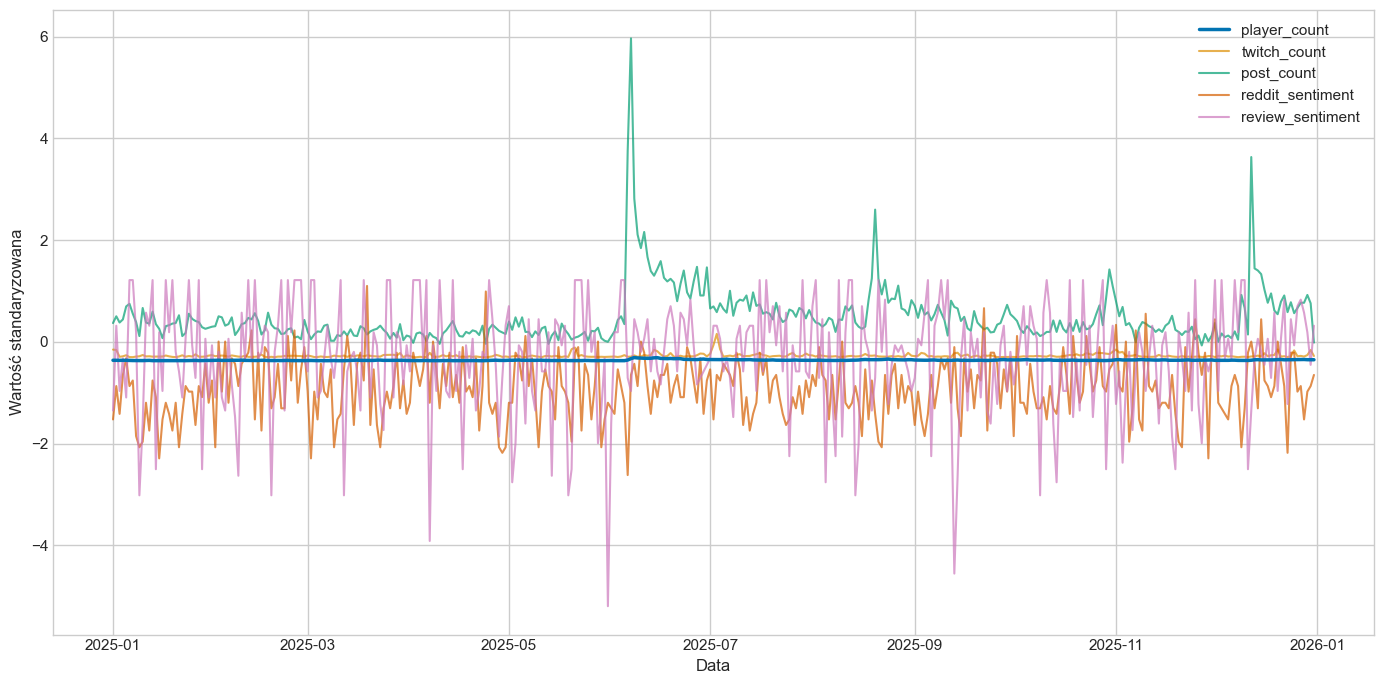

In [25]:
plt.figure(figsize=(14, 7))
highlight_var = "player_count" 

for variable in variables:
    if variable == highlight_var:
        alpha, linewidth, zorder = 1.0, 2.5, 5
    else:
        alpha, linewidth, zorder = 0.7, 1.5, 1 # Push non-highlighted lines to the back

    plt.plot(
        game_data["date"],
        game_data[variable],
        label=variable,
        alpha=alpha,
        linewidth=linewidth,
        zorder=zorder
    )

#plt.title(f"Standaryzowane wartości zmiennych – {game}")
plt.xlabel("Data")
plt.ylabel("Wartość standaryzowana")
plt.legend()

plt.tight_layout()
plt.show()

#### 3.3.2 Analiza sezonowości
Wahania na poprzednich wykresach sugerują silną cykliczność. Aby ją potwierdzić, agregowane są dane do średniej w ujęciu poszczególnych dni tygodnia. 
Wykres wydaje się potwierdzać efekt weekendu: aktywność graczy dla tego tytułu spada w połowie tygodnia (środa-czwartek), a następnie drastycznie rośnie, osiągając swój szczyt w niedzielę.

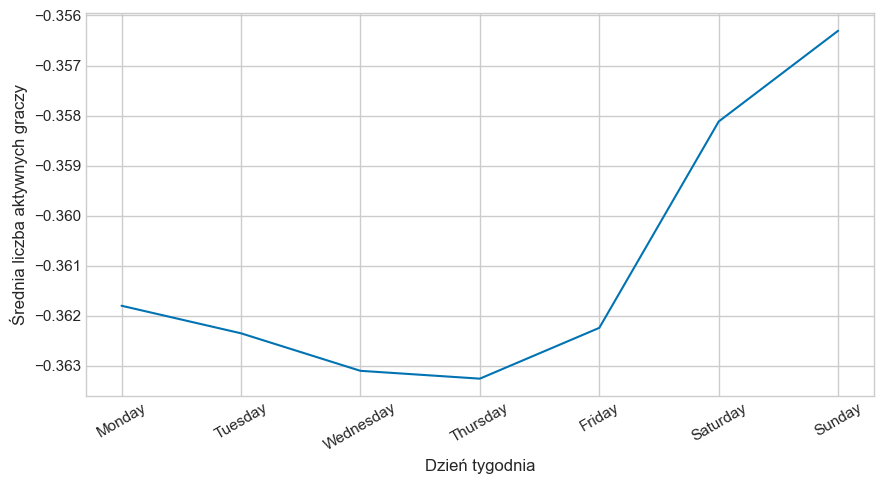

In [26]:
weekday_stats = (
    game_data
    .groupby("weekday")["player_count"]
    .mean()
)

plt.figure(figsize=(9, 5))

plt.plot(
    weekday_stats.index,
    weekday_stats.values,
)

#plt.title(
#    f"Średnia liczba aktywnych graczy według dnia tygodnia – {game}"
#)

plt.xlabel("Dzień tygodnia")
plt.ylabel("Średnia liczba aktywnych graczy")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

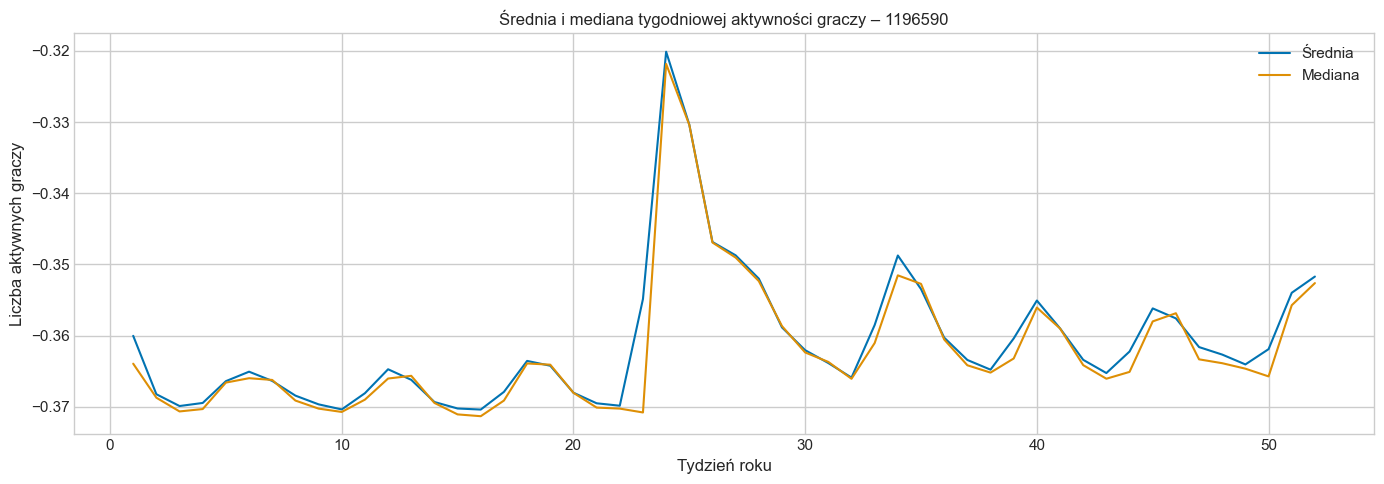

In [252]:
weekly = (
    game_data
    .groupby("week")["player_count"]
    .agg(["mean", "median"])
    .reset_index()
)

plt.figure(figsize=(14, 5))

plt.plot(
    weekly["week"],
    weekly["mean"],
    label="Średnia"
)

plt.plot(
    weekly["week"],
    weekly["median"],
    label="Mediana"
)

plt.title(
    f"Średnia i mediana tygodniowej aktywności graczy – {game}"
)

plt.xlabel("Tydzień roku")
plt.ylabel("Liczba aktywnych graczy")
plt.legend()

plt.tight_layout()
plt.show()

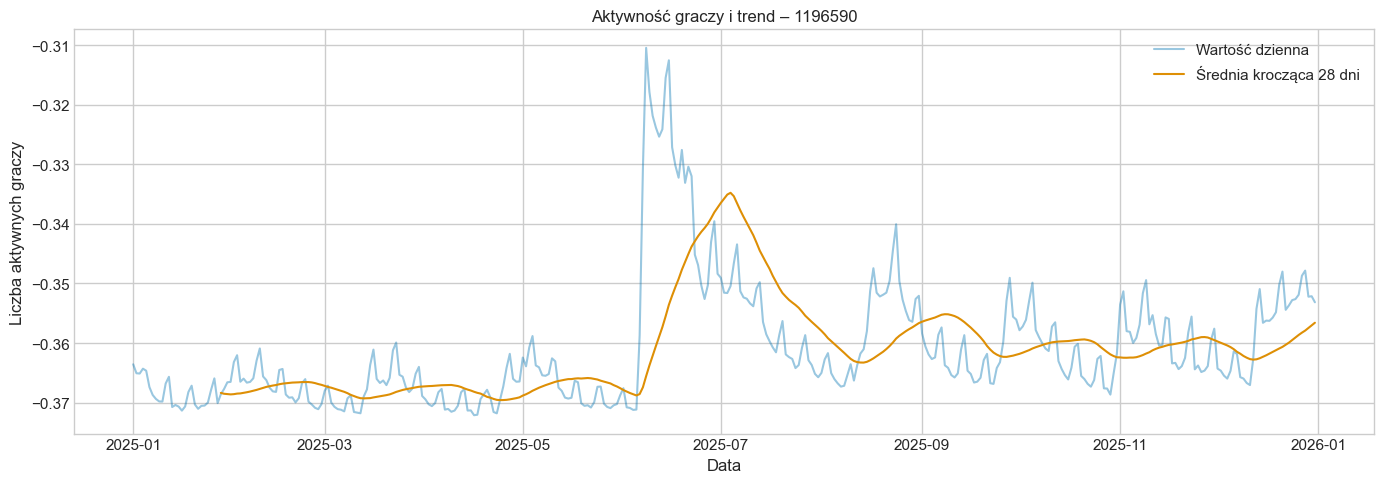

In [253]:
game_data["players_ma28"] = (
    game_data["player_count"]
    .rolling(28)
    .mean()
)
plt.figure(figsize=(14, 5))

plt.plot(
    game_data["date"],
    game_data["player_count"],
    alpha=0.4,
    label="Wartość dzienna"
)

plt.plot(
    game_data["date"],
    game_data["players_ma28"],
    label="Średnia krocząca 28 dni"
)

plt.title(f"Aktywność graczy i trend – {game}")
plt.xlabel("Data")
plt.ylabel("Liczba aktywnych graczy")
plt.legend()

plt.tight_layout()
plt.show()

#### 3.3.3 Analiza globalna – średnia i mediana dla całego rynku
Kolejnym krokiem jest spojrzenie na całą populację 81 tytułów. Wyliczono codzienną średnią i medianę dla wszystkich zmiennych w skali tygodniowej. 
Zestawienie średniej z medianą jest istotne – ze względu na prawoskośność danych (kilka "wielkich" gier zawyża średnią), mediana lepiej reprezentuje zachowanie i trend dla przeciętnej gry w zbiorze. Sprawdzono również, czy "efekt weekendu" zaobserwowany dla pojedynczej gry to reguła na całym rynku. Zgrupowanie i wyciągnięcie średniej dla wszystkich gier wydaje się to potwierdzać – najmniej osób gra w środy, a szczyt popularności całego ekosystemu przypada na soboty i niedziele.

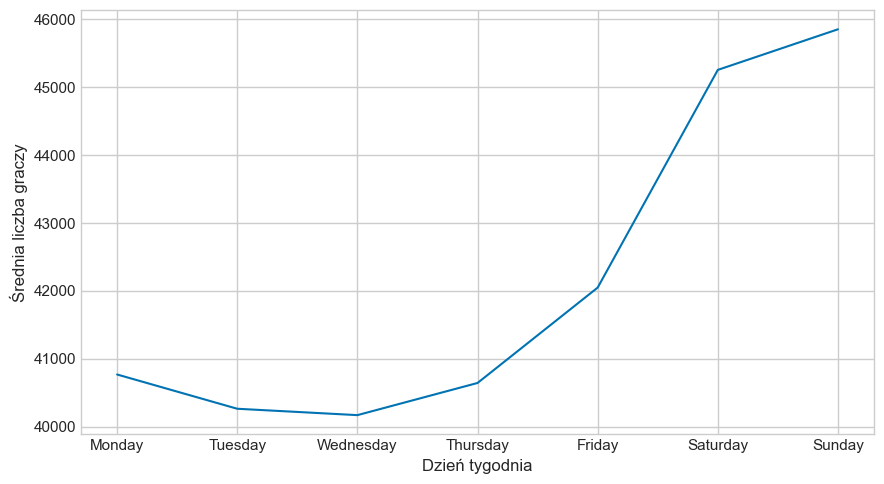

In [27]:
weekday_means = (
    panel_data
    .groupby("weekday", observed=True)["player_count"]
    .mean()
)

plt.figure(figsize=(9, 5))

plt.plot(
    weekday_means.index,
    weekday_means.values
)

#plt.title("Średnia liczba aktywnych graczy we wszystkich grach według dnia tygodnia")
plt.xlabel("Dzień tygodnia")
plt.ylabel("Średnia liczba graczy")

plt.tight_layout()
plt.show()

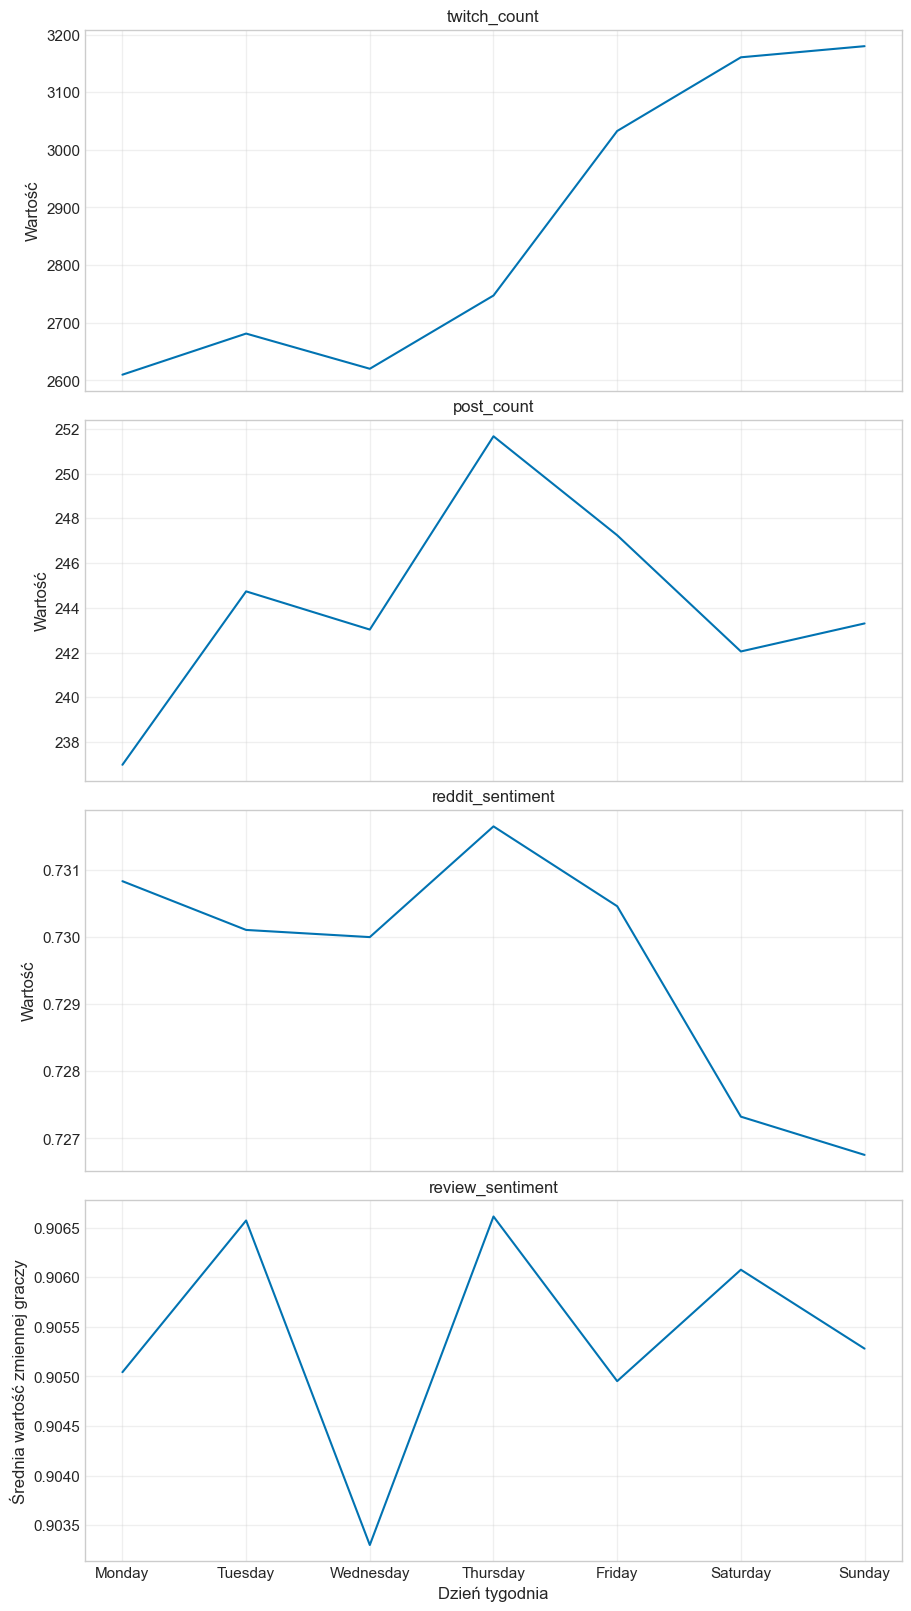

In [28]:
weekday_means_other_variables = (
    panel_data
    .groupby("weekday", observed=True)[variables_no_player_count]
    .mean()
)

fig, axes = plt.subplots(
    4, 1,
    figsize=(9, len(variable)),
    sharex=True,
    layout="constrained"
)

for ax, variable in zip(axes, variables_no_player_count):
    ax.plot(
        weekday_means_other_variables.index,
        weekday_means_other_variables[variable].values
    )

    ax.set_title(variable)
    ax.set_ylabel("Wartość")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("weekday")

#fig.suptitle("Średnia wartość zmiennej dla wszystkich gier według dnia tygodnia", fontsize=16)
plt.xlabel("Dzień tygodnia")
plt.ylabel("Średnia wartość zmiennej graczy")

plt.show()

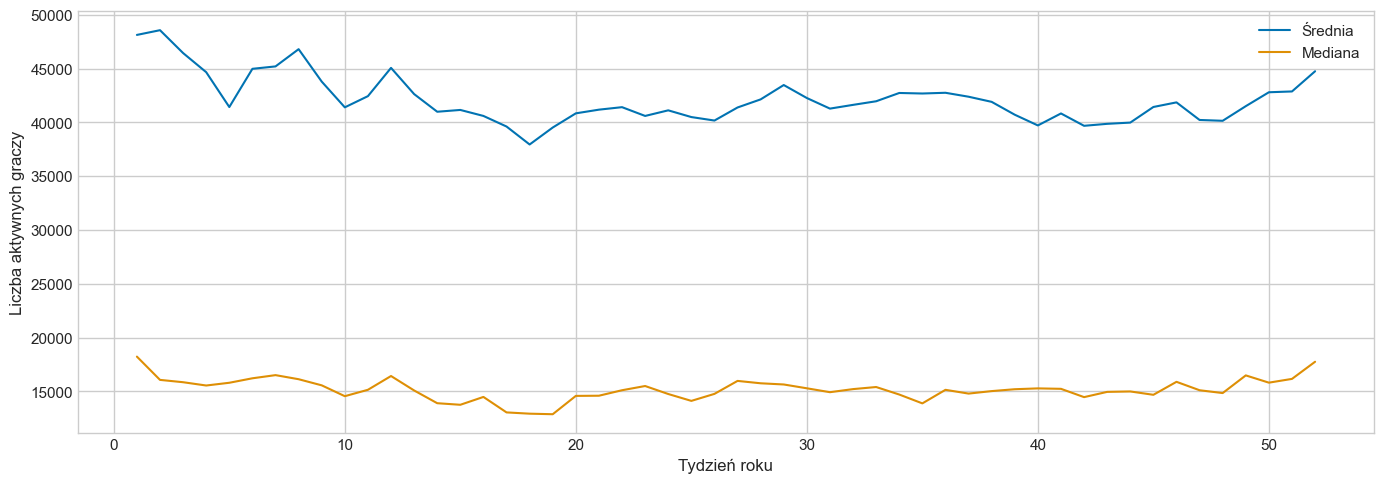

In [29]:
weekly = (
    panel_data
    .groupby("week")["player_count"]
    .agg(["mean", "median"])
    .reset_index()
)

plt.figure(figsize=(14, 5))

plt.plot(
    weekly["week"],
    weekly["mean"],
    label="Średnia"
)

plt.plot(
    weekly["week"],
    weekly["median"],
    label="Mediana"
)

#plt.title(
#    "Średnia i mediana tygodniowej aktywności graczy"
#)

plt.xlabel("Tydzień roku")
plt.ylabel("Liczba aktywnych graczy")
plt.legend()

plt.tight_layout()
plt.show()



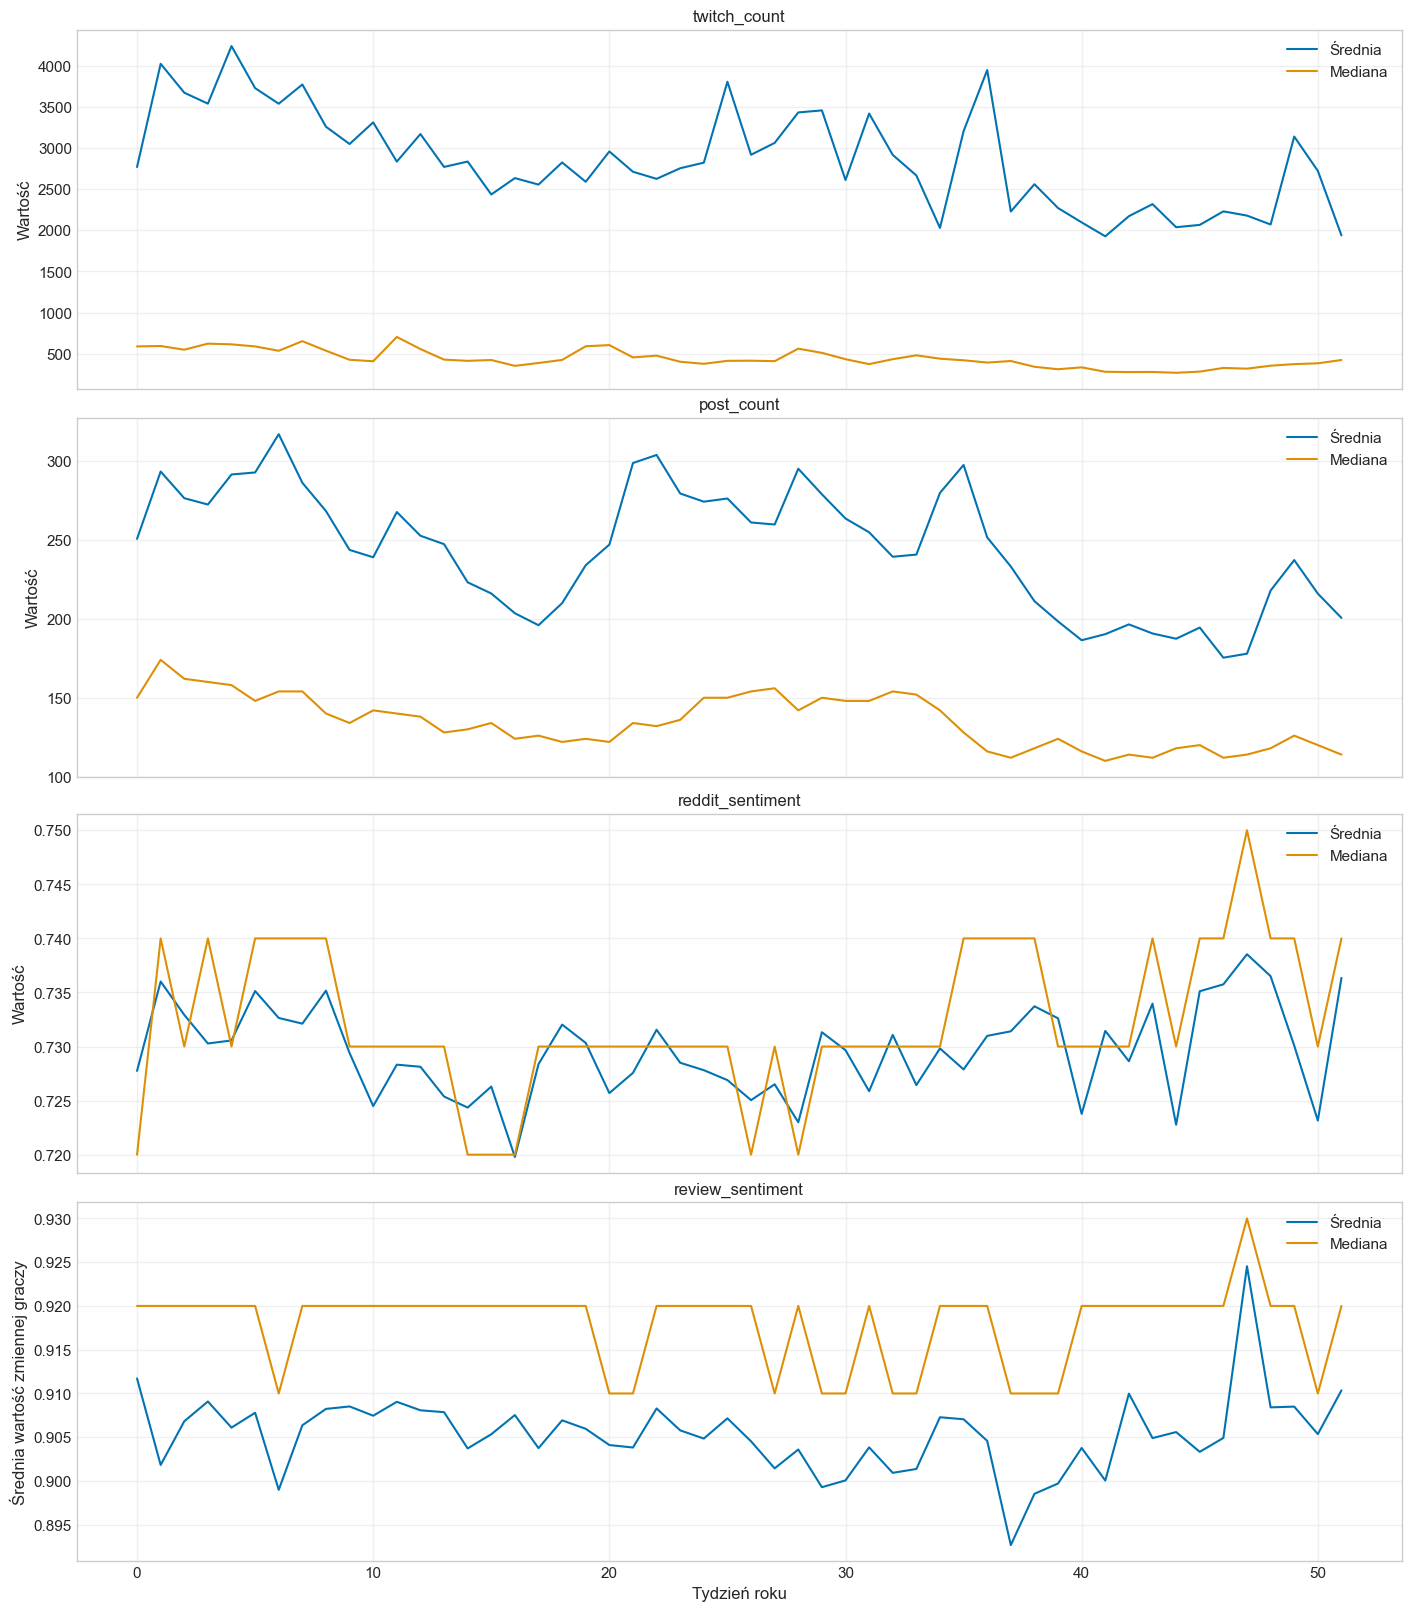

In [30]:
weekly_other_variables = (
    panel_data
    .groupby("week")[variables_no_player_count]
    .agg(["mean", "median"])
    .reset_index()
)

fig, axes = plt.subplots(
    4, 1,
    figsize=(14, len(variable)),
    sharex=True,
    layout="constrained"
)

for ax, variable in zip(axes, variables_no_player_count):
    ax.plot(
        weekly_other_variables.index, 
        weekly_other_variables[variable]["mean"], 
        label="Średnia"
    )
    
    # Rysowanie linii dla mediany
    ax.plot(
        weekly_other_variables.index, 
        weekly_other_variables[variable]["median"], 
        label="Mediana"
    )

    ax.set_title(variable)
    ax.set_ylabel("Wartość")
    ax.grid(alpha=0.3)
    ax.legend()

axes[-1].set_xlabel("week")

#fig.suptitle("Średnia i mediana tygodniowej aktywności graczy", fontsize=16)
plt.xlabel("Tydzień roku")
plt.ylabel("Średnia wartość zmiennej graczy")

plt.show()

#### 3.3.4 Macierz korelacji Pearsona
Na koniec podsumowano zależności pomiędzy wszystkimi wskaźnikami liczbowo, wyliczając współczynniki korelacji liniowej Pearsona na całym zbiorze danych.

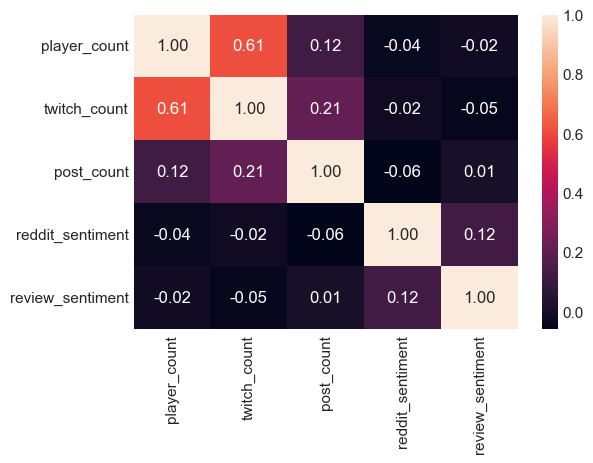

In [31]:
correlations = panel_data[variables].corr()

sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f"
)

#plt.title("Macierz korelacji zmiennych")
plt.tight_layout()
plt.show()

Kluczowe wnioski:
1. Najsilniejsza zależność (0.61) występuje między `player_count` a `twitch_count`. Popularność gry na platformach streamingowych idzie w parze z liczbą aktywnych graczy.
2. Zmienne sentymentu `reddit_sentiment`, `review_sentiment` są praktycznie ortogonalne (brak korelacji) względem liczby graczy (współczynniki bliskie zeru). Może to oznaczać, że wysoka popularność gry nie wiąże się automatycznie z wyższym (lub niższym) zadowoleniem graczy. Niszowe gry mogą być oceniane równie dobrze (lub źle) co największe rynkowe hity.